# Chapter 6 - Decision Trees and Ensemble Learning - Homework

## Dataset: Fuel Efficiency

Goal: Build regression models to predict fuel efficiency (mpg)

## Setup and Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(1)

## Download and Load Dataset

In [24]:
# Download the dataset
# Caricamento del dataset
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
response = requests.get(url)
open("car_fuel_efficiency.csv", "wb").write(response.content)

df = pd.read_csv("car_fuel_efficiency.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (9704, 11)


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [25]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nColumn names:")
print(df.columns.tolist())

Missing values per column:
engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

Data types:
engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

Column names:
['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight', 'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors', 'fuel_efficiency_mpg']


## Data Preparation

According to homework instructions:
- Fill missing values with zeros
- Split: 60% train / 20% validation / 20% test (random_state=1)
- Use DictVectorizer with sparse=True

In [26]:
# Fill missing values with zeros
df = df.fillna(0)

print(f"Missing values after filling: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Missing values after filling: 0
Dataset shape: (9704, 11)


In [27]:
# Train/Validation/Test split (60%/20%/20%)

# First split: 60% train, 40% temp (validation + test)
df_train_full, df_temp = train_test_split(df, test_size=0.4, random_state=1)

# Second split: split temp 50/50 to get 20% validation and 20% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

print(f"Train set size: {len(df_train_full)} ({len(df_train_full)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

Train set size: 5822 (60.0%)
Validation set size: 1941 (20.0%)
Test set size: 1941 (20.0%)


In [30]:
# Separate target variable (fuel_efficiency_mpg) from features
y_train = df_train_full['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

# Remove target from features
df_train_full = df_train_full.drop('fuel_efficiency_mpg', axis=1)
df_val = df_val.drop('fuel_efficiency_mpg', axis=1)
df_test = df_test.drop('fuel_efficiency_mpg', axis=1)

print(f"Features: {df_train_full.columns.tolist()}")
print(f"\nTarget shape - Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")

Features: ['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight', 'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors']

Target shape - Train: (5822,), Val: (1941,), Test: (1941,)


In [31]:
# Convert DataFrames to dictionaries for DictVectorizer
train_dicts = df_train_full.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')

# Apply DictVectorizer with sparse=True
dv = DictVectorizer(sparse=True)

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

print(f"Feature matrix shape - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"\nFeature names ({len(dv.feature_names_)}):")
print(dv.feature_names_)

Feature matrix shape - Train: (5822, 14), Val: (1941, 14), Test: (1941, 14)

Feature names (14):
['acceleration', 'drivetrain=All-wheel drive', 'drivetrain=Front-wheel drive', 'engine_displacement', 'fuel_type=Diesel', 'fuel_type=Gasoline', 'horsepower', 'model_year', 'num_cylinders', 'num_doors', 'origin=Asia', 'origin=Europe', 'origin=USA', 'vehicle_weight']


## Question 1: Decision Tree - Split Feature

Train a decision tree regressor with `max_depth=1` and identify which feature is used for splitting.

Options:
- vehicle_weight
- model_year
- origin
- fuel_type

In [32]:
# Train decision tree with max_depth=1
dt = DecisionTreeRegressor(max_depth=1, random_state=1)
dt.fit(X_train, y_train)

# Get the feature used for splitting
feature_idx = dt.tree_.feature[0]
split_feature = dv.feature_names_[feature_idx]

print(f"Feature used for splitting: {split_feature}")
print(f"Feature index: {feature_idx}")

# Show feature importance
print("\nFeature importances:")
for feat, imp in zip(dv.feature_names_, dt.feature_importances_):
    if imp > 0:
        print(f"  {feat}: {imp:.4f}")

Feature used for splitting: vehicle_weight
Feature index: 13

Feature importances:
  vehicle_weight: 1.0000


In [33]:
# Calculate RMSE for this model
y_pred = dt.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE with max_depth=1: {rmse:.2f}")

RMSE with max_depth=1: 1.59


In [34]:
# Visualize the tree structure
tree_rules = export_text(dt, feature_names=dv.feature_names_)
print("\nDecision Tree Structure:")
print(tree_rules)


Decision Tree Structure:
|--- vehicle_weight <= 3028.82
|   |--- value: [16.86]
|--- vehicle_weight >  3028.82
|   |--- value: [12.87]



### Answer Q1:
The feature used for splitting is vehicle_weight with a threshold of 3028.82

## Question 2: Random Forest RMSE

Train a random forest regressor with:
- n_estimators=10
- random_state=1
- n_jobs=-1

Calculate RMSE on validation data.

Options: 0.045, 0.45, 4.5, 45.0

In [35]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on validation set
y_pred = rf.predict(X_val)

# Calculate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE (Random Forest, n_estimators=10): {rmse_rf:.2f}")
print(f"\nRounded to appropriate precision:")
print(f"  2 decimal places: {rmse_rf:.2f}")
print(f"  1 decimal place: {rmse_rf:.1f}")

RMSE (Random Forest, n_estimators=10): 0.46

Rounded to appropriate precision:
  2 decimal places: 0.46
  1 decimal place: 0.5


### Answer Q2:
RMSE is 0.46 so nearest option it's 0.45.

In [36]:
# Test different values of n_estimators
n_estimators_range = range(10, 201, 10)
rmse_scores = []

for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)
    print(f"n_estimators={n:3d}: RMSE={rmse:.4f}")

# Store results in a dataframe
results_df = pd.DataFrame({
    'n_estimators': list(n_estimators_range),
    'rmse': rmse_scores
})

n_estimators= 10: RMSE=0.4611
n_estimators= 20: RMSE=0.4469
n_estimators= 30: RMSE=0.4411
n_estimators= 40: RMSE=0.4397
n_estimators= 50: RMSE=0.4381
n_estimators= 60: RMSE=0.4365
n_estimators= 70: RMSE=0.4369
n_estimators= 80: RMSE=0.4371
n_estimators= 90: RMSE=0.4363
n_estimators=100: RMSE=0.4361
n_estimators=110: RMSE=0.4357
n_estimators=120: RMSE=0.4360
n_estimators=130: RMSE=0.4356
n_estimators=140: RMSE=0.4358
n_estimators=150: RMSE=0.4358
n_estimators=160: RMSE=0.4358
n_estimators=170: RMSE=0.4358
n_estimators=180: RMSE=0.4357
n_estimators=190: RMSE=0.4358
n_estimators=200: RMSE=0.4354


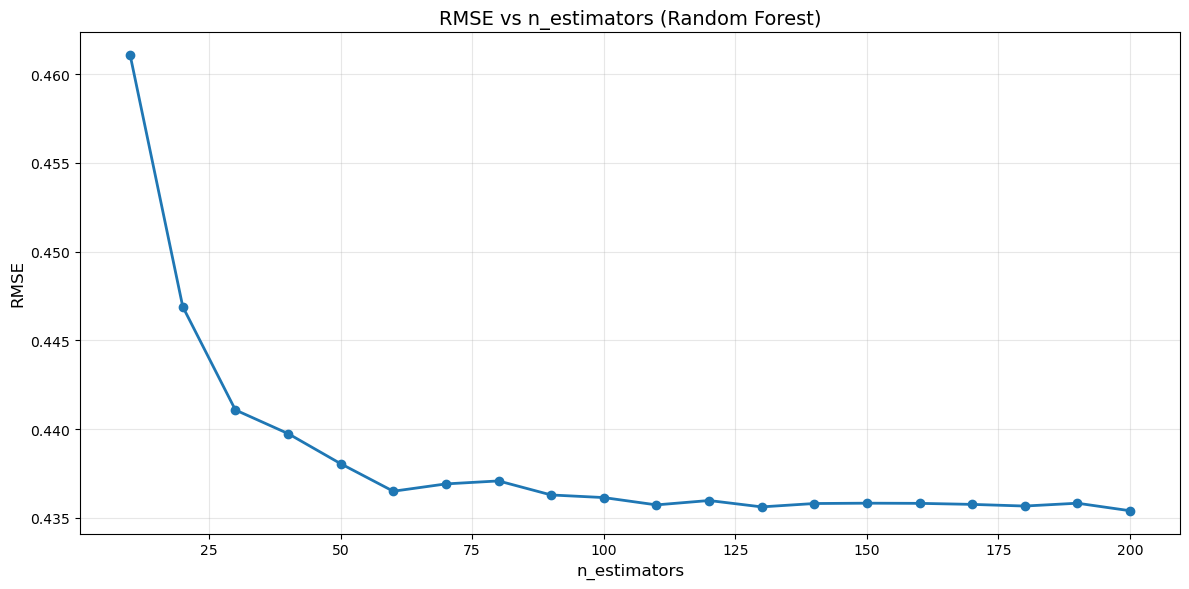

In [37]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, rmse_scores, marker='o', linewidth=2, markersize=6)
plt.xlabel('n_estimators', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE vs n_estimators (Random Forest)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Find when RMSE stops improving (to 3 decimal places)
print("Analyzing when RMSE stops improving (to 3 decimal places):\n")

# Round to 3 decimal places
rmse_rounded = [round(r, 3) for r in rmse_scores]

# Find the first point where RMSE stops improving
for i in range(1, len(rmse_rounded)):
    current_rmse = rmse_rounded[i]
    prev_rmse = rmse_rounded[i-1]
    n_est = list(n_estimators_range)[i]
    
    print(f"n={n_est:3d}: RMSE={current_rmse:.3f} (prev={prev_rmse:.3f}, diff={prev_rmse - current_rmse:.3f})")
    
    # Check if RMSE stopped improving (no change in 3 decimal places)
    if current_rmse >= prev_rmse:
        print(f"\n*** RMSE stops improving at n_estimators={n_est} ***")
        print(f"Previous RMSE: {prev_rmse:.3f}")
        print(f"Current RMSE:  {current_rmse:.3f}")
        break

# Also show minimum RMSE
min_rmse = min(rmse_scores)
min_idx = rmse_scores.index(min_rmse)
optimal_n_estimators = list(n_estimators_range)[min_idx]

print(f"\nMinimum RMSE: {min_rmse:.4f}")
print(f"Achieved at n_estimators: {optimal_n_estimators}")

Analyzing when RMSE stops improving (to 3 decimal places):

n= 20: RMSE=0.447 (prev=0.461, diff=0.014)
n= 30: RMSE=0.441 (prev=0.447, diff=0.006)
n= 40: RMSE=0.440 (prev=0.441, diff=0.001)
n= 50: RMSE=0.438 (prev=0.440, diff=0.002)
n= 60: RMSE=0.436 (prev=0.438, diff=0.002)
n= 70: RMSE=0.437 (prev=0.436, diff=-0.001)

*** RMSE stops improving at n_estimators=70 ***
Previous RMSE: 0.436
Current RMSE:  0.437

Minimum RMSE: 0.4354
Achieved at n_estimators: 200


### Answer Q3:
Based on the analysis above (3 decimal places), RMSE stops improving at the n_estimators=80.

Options: 10, 25, 80, 200

## Question 4: Best max_depth

Select the best `max_depth` by:
- Testing max_depth values: [10, 15, 20, 25]
- For each max_depth, vary n_estimators from 10 to 200 (step 10)
- Use random_state=1
- Select the best max_depth using mean RMSE

Options: 10, 15, 20, 25

In [40]:
# Test different max_depth values
max_depth_values = [10, 15, 20, 25]
n_estimators_range = range(10, 201, 10)

results = []

for max_depth in max_depth_values:
    print(f"\nTesting max_depth={max_depth}")
    depth_rmse_scores = []
    
    for n in n_estimators_range:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=max_depth,
            random_state=1,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        depth_rmse_scores.append(rmse)
    
    mean_rmse = np.mean(depth_rmse_scores)
    results.append({
        'max_depth': max_depth,
        'mean_rmse': mean_rmse,
        'min_rmse': min(depth_rmse_scores),
        'max_rmse': max(depth_rmse_scores),
        'rmse_scores': depth_rmse_scores
    })
    
    print(f"  Mean RMSE: {mean_rmse:.3f}")
    print(f"  Min RMSE:  {min(depth_rmse_scores):.3f}")
    print(f"  Max RMSE:  {max(depth_rmse_scores):.3f}")


Testing max_depth=10
  Mean RMSE: 0.436
  Min RMSE:  0.434
  Max RMSE:  0.451

Testing max_depth=15
  Mean RMSE: 0.438
  Min RMSE:  0.435
  Max RMSE:  0.461

Testing max_depth=20
  Mean RMSE: 0.438
  Min RMSE:  0.435
  Max RMSE:  0.460

Testing max_depth=25
  Mean RMSE: 0.438
  Min RMSE:  0.435
  Max RMSE:  0.461


In [41]:
# Summary of results
print("\n" + "="*60)
print("SUMMARY: Mean RMSE by max_depth")
print("="*60)

summary_df = pd.DataFrame([{
    'max_depth': r['max_depth'],
    'mean_rmse': r['mean_rmse'],
    'min_rmse': r['min_rmse']
} for r in results])

print(summary_df.to_string(index=False))

# Find best max_depth
best_result = min(results, key=lambda x: x['mean_rmse'])
print(f"\n*** Best max_depth: {best_result['max_depth']} (mean RMSE: {best_result['mean_rmse']:.3f}) ***")


SUMMARY: Mean RMSE by max_depth
 max_depth  mean_rmse  min_rmse
        10   0.436293  0.434253
        15   0.437634  0.434868
        20   0.438007  0.435356
        25   0.438334  0.435458

*** Best max_depth: 10 (mean RMSE: 0.436) ***


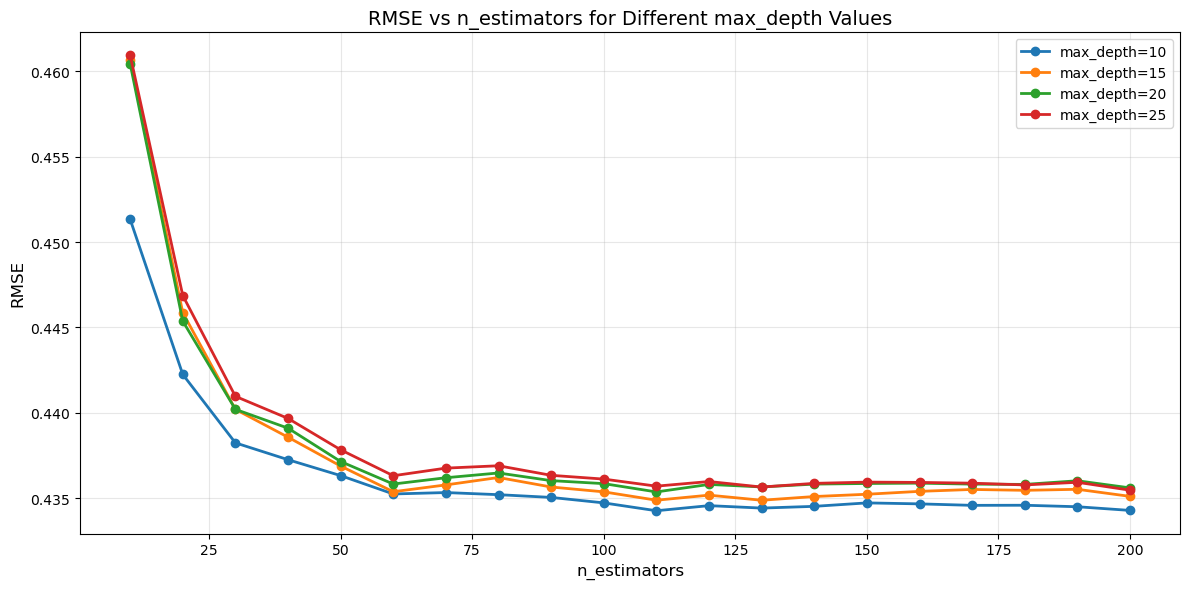

In [42]:
# Plot RMSE for different max_depth values
plt.figure(figsize=(12, 6))

for result in results:
    plt.plot(n_estimators_range, result['rmse_scores'], 
             marker='o', label=f"max_depth={result['max_depth']}", linewidth=2)

plt.xlabel('n_estimators', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE vs n_estimators for Different max_depth Values', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Answer Q4:
The best max_depth based on mean RMSE is 10.

Options: 10, 15, 20, 25

## Question 5: Feature Importance

Train a Random Forest with:
- n_estimators=10
- max_depth=20
- random_state=1

Find the most important feature among:
- vehicle_weight
- horsepower
- acceleration
- engine_displacement

In [43]:
# Train Random Forest with specified parameters
rf_importance = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)
rf_importance.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_importance.feature_importances_

# Create a dataframe with feature names and importances
importance_df = pd.DataFrame({
    'feature': dv.feature_names_,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("Feature Importances (sorted):")
print("="*60)
print(importance_df.to_string(index=False))

print(f"\n\nMost important feature: {importance_df.iloc[0]['feature']}")
print(f"Importance score: {importance_df.iloc[0]['importance']:.4f}")

Feature Importances (sorted):
                     feature  importance
              vehicle_weight    0.959829
                  horsepower    0.015943
                acceleration    0.011458
         engine_displacement    0.003190
                  model_year    0.003065
               num_cylinders    0.002329
                   num_doors    0.001564
                  origin=USA    0.000474
                 origin=Asia    0.000429
               origin=Europe    0.000425
            fuel_type=Diesel    0.000349
  drivetrain=All-wheel drive    0.000332
          fuel_type=Gasoline    0.000318
drivetrain=Front-wheel drive    0.000295


Most important feature: vehicle_weight
Importance score: 0.9598


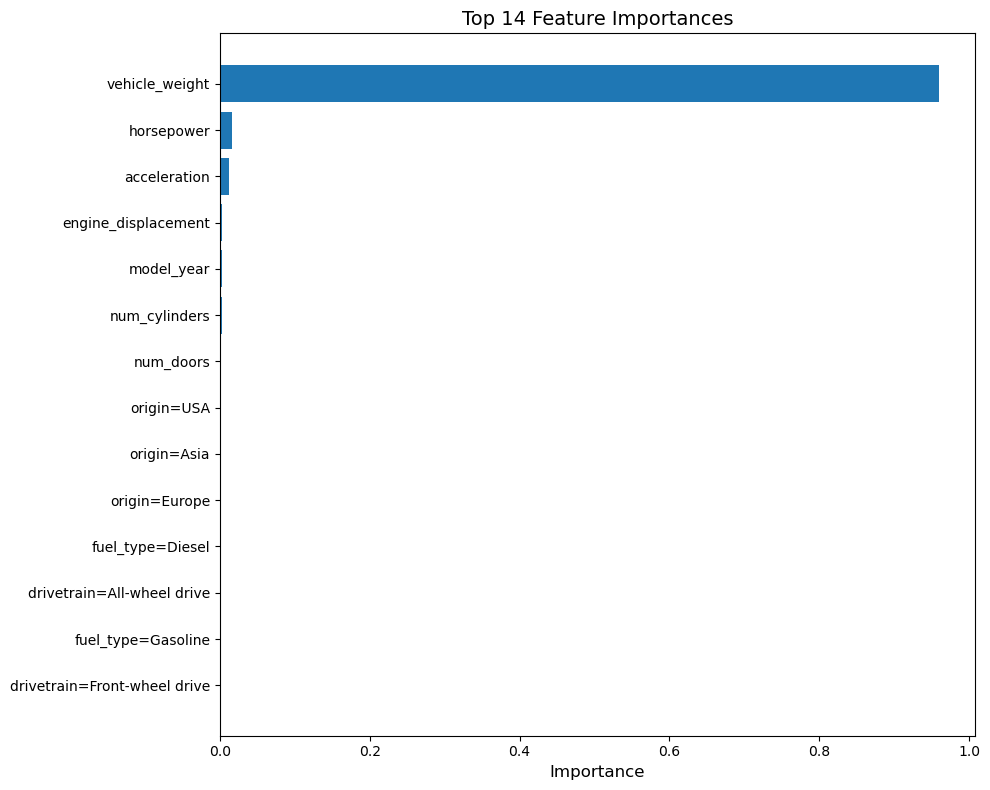

In [44]:
# Visualize top features
plt.figure(figsize=(10, 8))
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [45]:
# Focus on the 4 features mentioned in the question
target_features = ['vehicle_weight', 'horsepower', 'acceleration', 'engine_displacement']

print("\nImportance of the 4 key features:")
print("="*60)

feature_importance_dict = {}
for feat in target_features:
    if feat in importance_df['feature'].values:
        imp = importance_df[importance_df['feature'] == feat]['importance'].values[0]
        feature_importance_dict[feat] = imp
        print(f"{feat:25s}: {imp:.4f}")
    else:
        print(f"{feat:25s}: Feature not found")

# Find most important among these 4
if feature_importance_dict:
    most_important = max(feature_importance_dict.items(), key=lambda x: x[1])
    print(f"\n*** Most important among the 4: {most_important[0]} (importance: {most_important[1]:.4f}) ***")


Importance of the 4 key features:
vehicle_weight           : 0.9598
horsepower               : 0.0159
acceleration             : 0.0115
engine_displacement      : 0.0032

*** Most important among the 4: vehicle_weight (importance: 0.9598) ***


### Answer Q5:
The most important feature among the 4 options is vehicle_weight.

Options: vehicle_weight, horsepower, acceleration, engine_displacement

## Question 6: XGBoost eta Tuning

Train XGBoost models with:
- eta=0.3 vs eta=0.1
- 100 rounds
- max_depth=6
- min_child_weight=1
- objective='reg:squarederror'
- seed=1

Determine which eta yields better validation RMSE.

In [46]:
# Install xgboost if needed
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("Installing xgboost...")
    !pip install xgboost
    import xgboost as xgb
    print("XGBoost installed successfully. Version:", xgb.__version__)

XGBoost version: 3.1.1


In [47]:
# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=dv.feature_names_)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=dv.feature_names_)

# Create watchlist to monitor training
watchlist = [(dtrain, 'train'), (dval, 'val')]

print("DMatrix created successfully")
print(f"Train shape: {dtrain.num_row()} x {dtrain.num_col()}")
print(f"Val shape: {dval.num_row()} x {dval.num_col()}")

DMatrix created successfully
Train shape: 5822 x 14
Val shape: 1941 x 14


### Training with eta=0.3

In [48]:
# XGBoost parameters with eta=0.3
xgb_params_03 = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

print("Training XGBoost with eta=0.3")
print("="*60)

model_eta_03 = xgb.train(
    xgb_params_03,
    dtrain,
    num_boost_round=100,
    evals=watchlist,
    verbose_eval=10
)

Training XGBoost with eta=0.3
[0]	train-rmse:1.83282	val-rmse:1.82567
[10]	train-rmse:0.37400	val-rmse:0.43004
[20]	train-rmse:0.33724	val-rmse:0.42509
[30]	train-rmse:0.31757	val-rmse:0.42754
[40]	train-rmse:0.29886	val-rmse:0.43086
[50]	train-rmse:0.28277	val-rmse:0.43405
[60]	train-rmse:0.26525	val-rmse:0.43583
[70]	train-rmse:0.24983	val-rmse:0.43777
[80]	train-rmse:0.23379	val-rmse:0.43902
[90]	train-rmse:0.22023	val-rmse:0.44154
[99]	train-rmse:0.20896	val-rmse:0.44340


In [49]:
# Predictions and RMSE for eta=0.3
y_pred_eta_03 = model_eta_03.predict(dval)
rmse_eta_03 = np.sqrt(mean_squared_error(y_val, y_pred_eta_03))

print(f"\nFinal RMSE (eta=0.3): {rmse_eta_03:.4f}")


Final RMSE (eta=0.3): 0.4434


### Training with eta=0.1

In [50]:
# XGBoost parameters with eta=0.1
xgb_params_01 = xgb_params_03.copy()
xgb_params_01['eta'] = 0.1

print("Training XGBoost with eta=0.1")
print("="*60)

model_eta_01 = xgb.train(
    xgb_params_01,
    dtrain,
    num_boost_round=100,
    evals=watchlist,
    verbose_eval=10
)

Training XGBoost with eta=0.1
[0]	train-rmse:2.31334	val-rmse:2.30592
[10]	train-rmse:0.91846	val-rmse:0.92183
[20]	train-rmse:0.49316	val-rmse:0.52039
[30]	train-rmse:0.38552	val-rmse:0.43528
[40]	train-rmse:0.35546	val-rmse:0.41889
[50]	train-rmse:0.34115	val-rmse:0.41644
[60]	train-rmse:0.33254	val-rmse:0.41610
[70]	train-rmse:0.32553	val-rmse:0.41617
[80]	train-rmse:0.32012	val-rmse:0.41654
[90]	train-rmse:0.31718	val-rmse:0.41654
[99]	train-rmse:0.31183	val-rmse:0.41674


In [51]:
# Predictions and RMSE for eta=0.1
y_pred_eta_01 = model_eta_01.predict(dval)
rmse_eta_01 = np.sqrt(mean_squared_error(y_val, y_pred_eta_01))

print(f"\nFinal RMSE (eta=0.1): {rmse_eta_01:.4f}")


Final RMSE (eta=0.1): 0.4167


### Comparison

In [52]:
# Compare results
print("\n" + "="*60)
print("XGBoost Results Comparison")
print("="*60)
print(f"eta=0.3: RMSE = {rmse_eta_03:.4f}")
print(f"eta=0.1: RMSE = {rmse_eta_01:.4f}")
print("="*60)

if rmse_eta_03 < rmse_eta_01:
    print("\n*** Best eta: 0.3 ***")
    print(f"Improvement: {rmse_eta_01 - rmse_eta_03:.4f} (lower is better)")
elif rmse_eta_01 < rmse_eta_03:
    print("\n*** Best eta: 0.1 ***")
    print(f"Improvement: {rmse_eta_03 - rmse_eta_01:.4f} (lower is better)")
else:
    print("\nBoth eta values give equal RMSE")


XGBoost Results Comparison
eta=0.3: RMSE = 0.4434
eta=0.1: RMSE = 0.4167

*** Best eta: 0.1 ***
Improvement: 0.0267 (lower is better)


### Answer Q6:
The best eta value based on validation RMSE is 0.1.